In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os


try:
    path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
    data = pd.read_csv(os.path.join(path, 'Wednesday-workingHours.pcap_ISCX.csv' ))
    print('Wednesday data confirmed. :)')

except Exception as e:
    print(f'Something went wrong {e}')

data.head()

Wednesday data confirmed. :)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
from sklearn.preprocessing import LabelEncoder

data.columns = data.columns.str.strip()

le = LabelEncoder()

columns_drop = [
    'Fwd Header Length.1'
]


data['Label'] = le.fit_transform(data['Label'])

data.replace([np.inf, -np.inf], np.nan, inplace= True )
data.dropna(inplace = True)

data = data.drop(columns=columns_drop, errors='ignore')


X = data.drop('Label', axis=1)
y = data['Label']

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=1)

In [4]:
from  xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx] 

    xgb = XGBClassifier(eval_metric='mlogloss', random_state=1)
    xgb.fit(X_train, y_train)


    y_pred = xgb.predict(X_test)
    print('-Fold--')
    print(classification_report(y_test, y_pred))

-Fold--
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     87937
           1       1.00      1.00      1.00      2058
           2       1.00      1.00      1.00     46025
           3       1.00      0.99      1.00      1100
           4       0.99      1.00      1.00      1159
           5       1.00      1.00      1.00         3

    accuracy                           1.00    138282
   macro avg       1.00      1.00      1.00    138282
weighted avg       1.00      1.00      1.00    138282

-Fold--
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     87937
           1       1.00      1.00      1.00      2058
           2       1.00      1.00      1.00     46025
           3       1.00      0.99      0.99      1100
           4       0.99      0.99      0.99      1159
           5       1.00      1.00      1.00         2

    accuracy                           1.00    138281
   macr

6
1.0
[4.0179033e-02 1.2106898e-04 3.0939071e-03 1.6162654e-02 1.6322840e-03
 1.0492450e-02 1.9800989e-03 9.2113707e-03 2.9454261e-04 1.6345807e-04
 1.0960946e-02 6.8552564e-03 3.1290841e-03 3.3791912e-01 7.3148153e-04
 4.3831006e-04 8.2371151e-03 1.7253372e-03 3.5638903e-05 3.0797720e-03
 9.0287787e-05 6.2446547e-05 1.0573037e-03 4.0347561e-05 3.0652294e-03
 3.9606970e-03 1.0125637e-02 9.3318401e-03 1.9126732e-03 4.1066860e-03
 3.6168727e-03 0.0000000e+00 0.0000000e+00 0.0000000e+00 2.6358303e-03
 4.1114334e-03 1.2629018e-03 4.7100764e-02 1.4617641e-01 1.4922105e-03
 1.9221258e-01 9.2795299e-04 2.0452116e-02 0.0000000e+00 0.0000000e+00
 3.3352810e-03 2.7723776e-05 2.7214442e-03 0.0000000e+00 0.0000000e+00
 8.2772854e-04 3.0879715e-02 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00
 0.0000000e+00 0.0000000e+00 0.0000000e+00 4.0503368e-03 7.1684183e-03
 2.1906558e-03 1.0031883e-03 1.6921353e-04 2.1685904e-02 3.5309934e-04


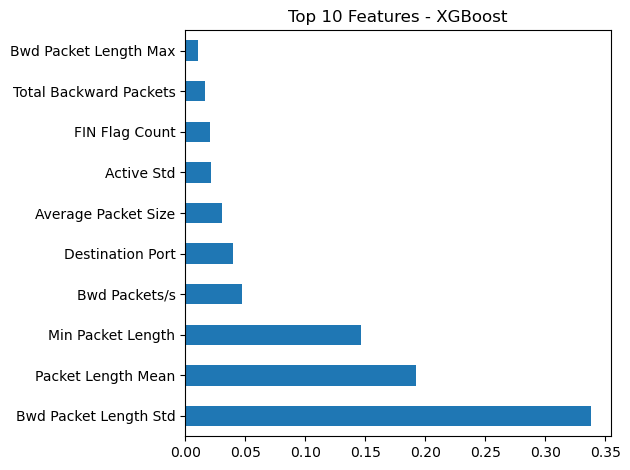

In [5]:
import matplotlib.pyplot as plt

xgb_importance = XGBClassifier(eval_metric='mlogloss', random_state=1)
xgb_importance.fit(X,y)


print(xgb_importance.n_classes_)
print(xgb_importance.feature_importances_.sum())
print(xgb_importance.feature_importances_)

importance = pd.Series(xgb_importance.feature_importances_, index=X.columns)
print(importance.nlargest(10))

importance.nlargest(10).plot(kind='barh')
plt.title('Top 10 Features - XGBoost')
plt.tight_layout()
plt.show()